In [2]:
import pandas as pd
import numpy as np

DATA_FILE_PATH = "../data/PAMAP2_Dataset/Protocol/subject10{subject_number}.dat"
OPTIONAL_DATA_FILE_PATH = "../data/PAMAP2_Dataset/Optional/subject10{subject_number}.dat"

# Cargar Dataset

## Definir procedimiento para generar las columnas del dataframe resultante

In [5]:
SENSORS = ["imu_hand", "imu_chest", "imu_ankle"]
IMU_SENSORY_COLUMNS = {
    "3d_acc16": ["x","y","z"],
    "3d_acc6": ["x","y","z"],
    "3d_gyro": ["x","y","z"],
    "3d_mag": ["x","y","z"],
    "orientation": [1,2,3,4]
}

orientation_columns = []
def get_subject_df_columns(data_file_path = DATA_FILE_PATH):
    df_columns = ["timestamp", "activity_id", "hearth_rate"]
    
    sensor_columns = []
    for sensor in SENSORS:
        sensor_columns.extend(get_sensor_columns(sensor))
    
    df_columns.extend(sensor_columns)

    return df_columns

def get_sensor_columns(sensor: str):
    sensor_columns = [f"{sensor}_temp"]
    for sensor_column in IMU_SENSORY_COLUMNS.keys():
        sensor_columns.extend([f"{sensor}_{sensor_column}_{coord}" for coord in IMU_SENSORY_COLUMNS[sensor_column]])
    return sensor_columns
    
get_subject_df_columns()

['timestamp',
 'activity_id',
 'hearth_rate',
 'imu_hand_temp',
 'imu_hand_3d_acc16_x',
 'imu_hand_3d_acc16_y',
 'imu_hand_3d_acc16_z',
 'imu_hand_3d_acc6_x',
 'imu_hand_3d_acc6_y',
 'imu_hand_3d_acc6_z',
 'imu_hand_3d_gyro_x',
 'imu_hand_3d_gyro_y',
 'imu_hand_3d_gyro_z',
 'imu_hand_3d_mag_x',
 'imu_hand_3d_mag_y',
 'imu_hand_3d_mag_z',
 'imu_hand_orientation_1',
 'imu_hand_orientation_2',
 'imu_hand_orientation_3',
 'imu_hand_orientation_4',
 'imu_chest_temp',
 'imu_chest_3d_acc16_x',
 'imu_chest_3d_acc16_y',
 'imu_chest_3d_acc16_z',
 'imu_chest_3d_acc6_x',
 'imu_chest_3d_acc6_y',
 'imu_chest_3d_acc6_z',
 'imu_chest_3d_gyro_x',
 'imu_chest_3d_gyro_y',
 'imu_chest_3d_gyro_z',
 'imu_chest_3d_mag_x',
 'imu_chest_3d_mag_y',
 'imu_chest_3d_mag_z',
 'imu_chest_orientation_1',
 'imu_chest_orientation_2',
 'imu_chest_orientation_3',
 'imu_chest_orientation_4',
 'imu_ankle_temp',
 'imu_ankle_3d_acc16_x',
 'imu_ankle_3d_acc16_y',
 'imu_ankle_3d_acc16_z',
 'imu_ankle_3d_acc6_x',
 'imu_ankle_3d_

## Crear un dataframe por cada archivo de cada sujeto de prueba del dataset

In [7]:
subject_1_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=1), delimiter=" ", names=get_subject_df_columns())
subject_1_optional_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=1), delimiter=" ", names=get_subject_df_columns(OPTIONAL_DATA_FILE_PATH))

subject_2_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=2), delimiter=" ", names=get_subject_df_columns())

subject_3_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=3), delimiter=" ", names=get_subject_df_columns())

subject_4_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=4), delimiter=" ", names=get_subject_df_columns())

subject_5_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=5), delimiter=" ", names=get_subject_df_columns())
subject_5_optional_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=5), delimiter=" ", names=get_subject_df_columns(OPTIONAL_DATA_FILE_PATH))

subject_6_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=6), delimiter=" ", names=get_subject_df_columns())
subject_6_optional_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=6), delimiter=" ", names=get_subject_df_columns(OPTIONAL_DATA_FILE_PATH))

subject_7_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=7), delimiter=" ", names=get_subject_df_columns())

subject_8_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=8), delimiter=" ", names=get_subject_df_columns())
subject_8_optional_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=8), delimiter=" ", names=get_subject_df_columns(OPTIONAL_DATA_FILE_PATH))

subject_9_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=9), delimiter=" ", names=get_subject_df_columns())
subject_9_optional_df = pd.read_csv(DATA_FILE_PATH.format(subject_number=9), delimiter=" ", names=get_subject_df_columns(OPTIONAL_DATA_FILE_PATH))


## Concatenar todos los dataframes creados en uno solo que represente el dataset completo

In [9]:
all_subjects_df = pd.concat([
    subject_1_df, 
    subject_2_df, 
    subject_3_df, 
    subject_4_df, 
    subject_5_df, 
    subject_6_df, 
    subject_7_df, 
    subject_8_df, 
    subject_9_df,
    subject_1_optional_df,
    subject_5_optional_df,
    subject_6_optional_df,
    subject_8_optional_df,
    subject_9_optional_df
])

In [ ]:
all_subjects_df

# Limpieza y Transformacion del dataframe

## Seguir recomendaciones de la documentación del dataset para remover columnas

In [13]:

df_columns_no_orientation = [ column for column in all_subjects_df.columns if  "orientation" not in column] # remover columnas de orientacion
final_df_columns = [ column for column in df_columns_no_orientation if "acc6" not in column ] # remover acelerometros de +-6g

all_subjects_df = all_subjects_df[final_df_columns]

all_subjects_df = all_subjects_df.loc[all_subjects_df["activity_id"] != 0] # remover la clase 0 (transicion entre actividades)

all_subjects_df.head()

,timestamp,activity_id,hearth_rate,imu_hand_temp,imu_hand_3d_acc16_x,imu_hand_3d_acc16_y,imu_hand_3d_acc16_z,imu_hand_3d_gyro_x,imu_hand_3d_gyro_y,imu_hand_3d_gyro_z,...,imu_ankle_temp,imu_ankle_3d_acc16_x,imu_ankle_3d_acc16_y,imu_ankle_3d_acc16_z,imu_ankle_3d_gyro_x,imu_ankle_3d_gyro_y,imu_ankle_3d_gyro_z,imu_ankle_3d_mag_x,imu_ankle_3d_mag_y,imu_ankle_3d_mag_z
2928,37.66,1,NaN,30.375,2.21530,8.27915,5.58753,-0.004750,0.037579,-0.011145,...,30.75,9.73855,-1.84761,0.095156,0.002908,-0.027714,0.001752,-61.1081,-36.8636,-58.3696
2929,37.67,1,NaN,30.375,2.29196,7.67288,5.74467,-0.171710,0.025479,-0.009538,...,30.75,9.69762,-1.88438,-0.020804,0.020882,0.000945,0.006007,-60.8916,-36.3197,-58.3656
2930,37.68,1,NaN,30.375,2.29090,7.14240,5.82342,-0.238241,0.011214,0.000831,...,30.75,9.69633,-1.92203,-0.059173,-0.035392,-0.052422,-0.004882,-60.3407,-35.7842,-58.6119
2931,37.69,1,NaN,30.375,2.21800,7.14365,5.89930,-0.192912,0.019053,0.013374,...,30.75,9.66370,-1.84714,0.094385,-0.032514,-0.018844,0.026950,-60.7646,-37.1028,-57.8799
2932,37.70,1,100.0,30.375,2.30106,7.25857,6.09259,-0.069961,-0.018328,0.004582,...,30.75,9.77578,-1.88582,0.095775,0.001351,-0.048878,-0.006328,-60.2040,-37.1225,-57.8847


## Convertir las columnas timestamp y activity_id en un multi indice

In [15]:
all_subjects_df.set_index(['timestamp', 'activity_id'], inplace=True)

In [16]:
all_subjects_df

,,hearth_rate,imu_hand_temp,imu_hand_3d_acc16_x,imu_hand_3d_acc16_y,imu_hand_3d_acc16_z,imu_hand_3d_gyro_x,imu_hand_3d_gyro_y,imu_hand_3d_gyro_z,imu_hand_3d_mag_x,imu_hand_3d_mag_y,...,imu_ankle_temp,imu_ankle_3d_acc16_x,imu_ankle_3d_acc16_y,imu_ankle_3d_acc16_z,imu_ankle_3d_gyro_x,imu_ankle_3d_gyro_y,imu_ankle_3d_gyro_z,imu_ankle_3d_mag_x,imu_ankle_3d_mag_y,imu_ankle_3d_mag_z
timestamp,activity_id,,,,,,,,,,,,,,,,,,,,,
37.66,1,NaN,30.375,2.21530,8.27915,5.58753,-0.004750,0.037579,-0.011145,8.93200,-67.9326,...,30.75,9.73855,-1.84761,0.095156,0.002908,-0.027714,0.001752,-61.1081,-36.863600,-58.369600
37.67,1,NaN,30.375,2.29196,7.67288,5.74467,-0.171710,0.025479,-0.009538,9.58300,-67.9584,...,30.75,9.69762,-1.88438,-0.020804,0.020882,0.000945,0.006007,-60.8916,-36.319700,-58.365600
37.68,1,NaN,30.375,2.29090,7.14240,5.82342,-0.238241,0.011214,0.000831,9.05516,-67.4017,...,30.75,9.69633,-1.92203,-0.059173,-0.035392,-0.052422,-0.004882,-60.3407,-35.784200,-58.611900
37.69,1,NaN,30.375,2.21800,7.14365,5.89930,-0.192912,0.019053,0.013374,9.92698,-67.4387,...,30.75,9.66370,-1.84714,0.094385,-0.032514,-0.018844,0.026950,-60.7646,-37.102800,-57.879900
37.70,1,100.0,30.375,2.30106,7.25857,6.09259,-0.069961,-0.018328,0.004582,9.15626,-67.1825,...,30.75,9.77578,-1.88582,0.095775,0.001351,-0.048878,-0.006328,-60.2040,-37.122500,-57.884700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95.06,24,NaN,25.125,4.99466,6.01881,5.59830,-0.289166,-0.110170,0.238570,-4.79353,-18.1271,...,31.50,9.40727,-2.24401,-2.259740,0.021288,-0.012885,0.005878,-45.7855,-0.831734,-0.170139
95.07,24,NaN,25.125,5.02764,5.90369,5.48372,-0.275411,-0.128358,0.267409,-4.54101,-18.0169,...,31.50,9.36745,-2.28110,-2.337100,0.010715,0.003629,-0.004235,-46.0331,-0.817288,0.538134
95.08,24,NaN,25.125,5.06409,5.71370,5.48491,-0.289885,-0.126548,0.281483,-4.17401,-17.9121,...,31.50,9.36765,-2.24313,-2.337340,-0.016939,-0.035176,-0.002309,-45.5140,-1.229410,0.540438


## Manejar datos Nulos

In [18]:
null_values_per_column = pd.DataFrame(all_subjects_df.isnull().sum())
null_values_per_column.rename(columns={0: "Total Null"}, inplace=True)
null_values_per_column["Percentage"] = all_subjects_df.isna().mean() * 100
null_values_per_column

,Total Null,Percentage
hearth_rate,2711454,90.870684
imu_hand_temp,15764,0.528309
imu_hand_3d_acc16_x,15764,0.528309
imu_hand_3d_acc16_y,15764,0.528309
imu_hand_3d_acc16_z,15764,0.528309
imu_hand_3d_gyro_x,15764,0.528309
imu_hand_3d_gyro_y,15764,0.528309
imu_hand_3d_gyro_z,15764,0.528309
imu_hand_3d_mag_x,15764,0.528309
imu_hand_3d_mag_y,15764,0.528309


### Eliminar Columna Hearth Rate

In [20]:
all_subjects_df.drop("hearth_rate", axis=1, inplace=True)
all_subjects_df

,,imu_hand_temp,imu_hand_3d_acc16_x,imu_hand_3d_acc16_y,imu_hand_3d_acc16_z,imu_hand_3d_gyro_x,imu_hand_3d_gyro_y,imu_hand_3d_gyro_z,imu_hand_3d_mag_x,imu_hand_3d_mag_y,imu_hand_3d_mag_z,...,imu_ankle_temp,imu_ankle_3d_acc16_x,imu_ankle_3d_acc16_y,imu_ankle_3d_acc16_z,imu_ankle_3d_gyro_x,imu_ankle_3d_gyro_y,imu_ankle_3d_gyro_z,imu_ankle_3d_mag_x,imu_ankle_3d_mag_y,imu_ankle_3d_mag_z
timestamp,activity_id,,,,,,,,,,,,,,,,,,,,,
37.66,1,30.375,2.21530,8.27915,5.58753,-0.004750,0.037579,-0.011145,8.93200,-67.9326,-19.9755,...,30.75,9.73855,-1.84761,0.095156,0.002908,-0.027714,0.001752,-61.1081,-36.863600,-58.369600
37.67,1,30.375,2.29196,7.67288,5.74467,-0.171710,0.025479,-0.009538,9.58300,-67.9584,-20.9091,...,30.75,9.69762,-1.88438,-0.020804,0.020882,0.000945,0.006007,-60.8916,-36.319700,-58.365600
37.68,1,30.375,2.29090,7.14240,5.82342,-0.238241,0.011214,0.000831,9.05516,-67.4017,-19.5083,...,30.75,9.69633,-1.92203,-0.059173,-0.035392,-0.052422,-0.004882,-60.3407,-35.784200,-58.611900
37.69,1,30.375,2.21800,7.14365,5.89930,-0.192912,0.019053,0.013374,9.92698,-67.4387,-20.5602,...,30.75,9.66370,-1.84714,0.094385,-0.032514,-0.018844,0.026950,-60.7646,-37.102800,-57.879900
37.70,1,30.375,2.30106,7.25857,6.09259,-0.069961,-0.018328,0.004582,9.15626,-67.1825,-20.0857,...,30.75,9.77578,-1.88582,0.095775,0.001351,-0.048878,-0.006328,-60.2040,-37.122500,-57.884700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95.06,24,25.125,4.99466,6.01881,5.59830,-0.289166,-0.110170,0.238570,-4.79353,-18.1271,-48.2695,...,31.50,9.40727,-2.24401,-2.259740,0.021288,-0.012885,0.005878,-45.7855,-0.831734,-0.170139
95.07,24,25.125,5.02764,5.90369,5.48372,-0.275411,-0.128358,0.267409,-4.54101,-18.0169,-48.9268,...,31.50,9.36745,-2.28110,-2.337100,0.010715,0.003629,-0.004235,-46.0331,-0.817288,0.538134
95.08,24,25.125,5.06409,5.71370,5.48491,-0.289885,-0.126548,0.281483,-4.17401,-17.9121,-48.4032,...,31.50,9.36765,-2.24313,-2.337340,-0.016939,-0.035176,-0.002309,-45.5140,-1.229410,0.540438


### Interpolar datos en sensores

In [22]:
all_subjects_df.interpolate(method="linear", inplace=True)

In [23]:
all_subjects_df

,,imu_hand_temp,imu_hand_3d_acc16_x,imu_hand_3d_acc16_y,imu_hand_3d_acc16_z,imu_hand_3d_gyro_x,imu_hand_3d_gyro_y,imu_hand_3d_gyro_z,imu_hand_3d_mag_x,imu_hand_3d_mag_y,imu_hand_3d_mag_z,...,imu_ankle_temp,imu_ankle_3d_acc16_x,imu_ankle_3d_acc16_y,imu_ankle_3d_acc16_z,imu_ankle_3d_gyro_x,imu_ankle_3d_gyro_y,imu_ankle_3d_gyro_z,imu_ankle_3d_mag_x,imu_ankle_3d_mag_y,imu_ankle_3d_mag_z
timestamp,activity_id,,,,,,,,,,,,,,,,,,,,,
37.66,1,30.375,2.21530,8.27915,5.58753,-0.004750,0.037579,-0.011145,8.93200,-67.9326,-19.9755,...,30.75,9.73855,-1.84761,0.095156,0.002908,-0.027714,0.001752,-61.1081,-36.863600,-58.369600
37.67,1,30.375,2.29196,7.67288,5.74467,-0.171710,0.025479,-0.009538,9.58300,-67.9584,-20.9091,...,30.75,9.69762,-1.88438,-0.020804,0.020882,0.000945,0.006007,-60.8916,-36.319700,-58.365600
37.68,1,30.375,2.29090,7.14240,5.82342,-0.238241,0.011214,0.000831,9.05516,-67.4017,-19.5083,...,30.75,9.69633,-1.92203,-0.059173,-0.035392,-0.052422,-0.004882,-60.3407,-35.784200,-58.611900
37.69,1,30.375,2.21800,7.14365,5.89930,-0.192912,0.019053,0.013374,9.92698,-67.4387,-20.5602,...,30.75,9.66370,-1.84714,0.094385,-0.032514,-0.018844,0.026950,-60.7646,-37.102800,-57.879900
37.70,1,30.375,2.30106,7.25857,6.09259,-0.069961,-0.018328,0.004582,9.15626,-67.1825,-20.0857,...,30.75,9.77578,-1.88582,0.095775,0.001351,-0.048878,-0.006328,-60.2040,-37.122500,-57.884700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95.06,24,25.125,4.99466,6.01881,5.59830,-0.289166,-0.110170,0.238570,-4.79353,-18.1271,-48.2695,...,31.50,9.40727,-2.24401,-2.259740,0.021288,-0.012885,0.005878,-45.7855,-0.831734,-0.170139
95.07,24,25.125,5.02764,5.90369,5.48372,-0.275411,-0.128358,0.267409,-4.54101,-18.0169,-48.9268,...,31.50,9.36745,-2.28110,-2.337100,0.010715,0.003629,-0.004235,-46.0331,-0.817288,0.538134
95.08,24,25.125,5.06409,5.71370,5.48491,-0.289885,-0.126548,0.281483,-4.17401,-17.9121,-48.4032,...,31.50,9.36765,-2.24313,-2.337340,-0.016939,-0.035176,-0.002309,-45.5140,-1.229410,0.540438


# Entrega de Avance

## Resumen estadístico de cada uno de los atributos de cada base de datos.

In [26]:
all_subjects_df.describe().map(lambda x: "{:.6f}".format(x))

,imu_hand_temp,imu_hand_3d_acc16_x,imu_hand_3d_acc16_y,imu_hand_3d_acc16_z,imu_hand_3d_gyro_x,imu_hand_3d_gyro_y,imu_hand_3d_gyro_z,imu_hand_3d_mag_x,imu_hand_3d_mag_y,imu_hand_3d_mag_z,...,imu_ankle_temp,imu_ankle_3d_acc16_x,imu_ankle_3d_acc16_y,imu_ankle_3d_acc16_z,imu_ankle_3d_gyro_x,imu_ankle_3d_gyro_y,imu_ankle_3d_gyro_z,imu_ankle_3d_mag_x,imu_ankle_3d_mag_y,imu_ankle_3d_mag_z
count,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,...,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000
mean,32.889112,-4.843648,3.387671,3.578807,0.000038,0.046751,-0.001720,20.833429,-13.678578,-24.626906,...,33.800492,9.417980,-0.082361,-2.735644,0.012904,-0.032144,0.006664,-32.916695,1.696246,17.220143
std,1.819763,6.439462,7.498813,3.989837,1.339092,0.974955,1.643468,24.795004,25.627833,20.434930,...,1.053295,6.732717,7.887772,4.017350,1.139250,0.651728,2.062535,18.852327,22.652890,20.222827
min,24.875000,-145.367000,-104.301000,-101.452000,-28.135400,-17.849500,-14.264700,-103.941000,-200.043000,-164.937000,...,30.000000,-155.068000,-157.443000,-158.926000,-23.995000,-18.126900,-14.019600,-172.865000,-137.908000,-102.716000
25%,31.750000,-8.903150,0.420176,1.163270,-0.393997,-0.228623,-0.402146,4.096430,-30.190400,-39.070800,...,33.187500,8.318600,-2.177410,-3.900440,-0.204569,-0.110806,-0.440697,-42.803900,-13.162025,3.498650
50%,33.375000,-5.263835,3.429915,3.470620,-0.006653,0.006191,-0.005545,22.703350,-15.742000,-24.097200,...,34.125000,9.515470,-0.274026,-2.549270,0.005230,-0.003182,-0.001845,-34.960000,1.846350,18.582450
75%,34.187500,-0.610451,6.555363,6.458592,0.345426,0.277628,0.395676,39.912600,3.978575,-11.551650,...,34.562500,10.339000,1.914550,-1.182610,0.148219,0.126630,0.108889,-18.618500,18.775600,31.335000
max,35.500000,62.859600,155.699000,157.760000,26.415800,23.077900,14.338400,137.544000,109.487000,101.758000,...,35.437500,157.232000,157.293000,158.872000,17.420400,13.588200,16.528800,91.551600,94.247800,146.900000


## Presenta la distribución de clases de cada base de datos.

In [28]:
CLASS_LABELS_ID = {
    1 : "lying",
    2 : "sitting",
    3 : "standing",
    4 : "walking",
    5 : "running",
    6 : "cycling",
    7 : "Nordic walking",
    9 : "watching TV",
    10 : "computer work",
    11 : "car driving",
    12 : "ascending stairs",
    13 : "descending stairs",
    16 : "vacuum cleaning",
    17 : "ironing",
    18 : "folding laundry",
    19 : "house cleaning",
    20 : "playing soccer",
    24 : "rope jumping"
}

In [29]:
class_distribution_series = all_subjects_df.index.get_level_values("activity_id").value_counts()

In [30]:
class_distribution_series.index = class_distribution_series.index.map(CLASS_LABELS_ID)

class_distribution_series

activity_id
ironing              366031
walking              350301
lying                290914
Nordic walking       290217
standing             283296
sitting              281496
vacuum cleaning      268109
cycling              258713
running              183467
ascending stairs     172361
descending stairs    153497
rope jumping          85458
Name: count, dtype: int64

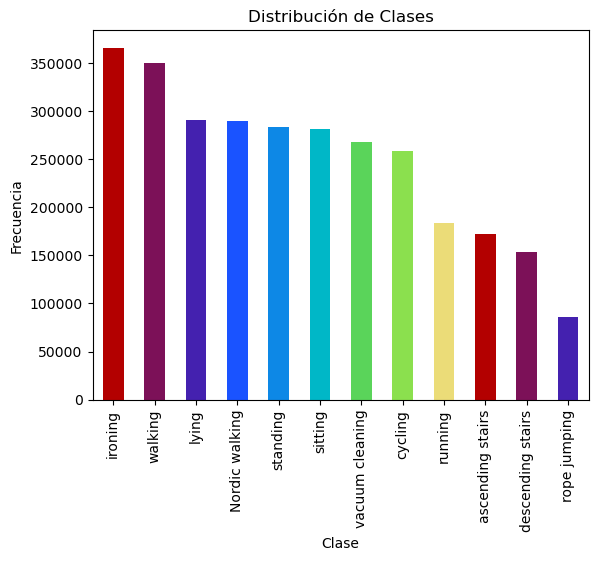

In [31]:
import matplotlib.pyplot as plt
from itertools import islice, cycle

bar_graph_colors = ["#b30000", "#7c1158", "#4421af", "#1a53ff", "#0d88e6", "#00b7c7", "#5ad45a", "#8be04e", "#ebdc78"]

class_distribution_series.plot(kind='bar', color=bar_graph_colors)
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.title('Distribución de Clases')
plt.show()

## Presenta la correlación entre atributos de cada base de datos.

In [33]:
all_subjects_df.corr().style.background_gradient(cmap='coolwarm')

,imu_hand_temp,imu_hand_3d_acc16_x,imu_hand_3d_acc16_y,imu_hand_3d_acc16_z,imu_hand_3d_gyro_x,imu_hand_3d_gyro_y,imu_hand_3d_gyro_z,imu_hand_3d_mag_x,imu_hand_3d_mag_y,imu_hand_3d_mag_z,imu_chest_temp,imu_chest_3d_acc16_x,imu_chest_3d_acc16_y,imu_chest_3d_acc16_z,imu_chest_3d_gyro_x,imu_chest_3d_gyro_y,imu_chest_3d_gyro_z,imu_chest_3d_mag_x,imu_chest_3d_mag_y,imu_chest_3d_mag_z,imu_ankle_temp,imu_ankle_3d_acc16_x,imu_ankle_3d_acc16_y,imu_ankle_3d_acc16_z,imu_ankle_3d_gyro_x,imu_ankle_3d_gyro_y,imu_ankle_3d_gyro_z,imu_ankle_3d_mag_x,imu_ankle_3d_mag_y,imu_ankle_3d_mag_z
imu_hand_temp,1.000000,0.045782,-0.055074,0.096871,-0.025691,-0.034651,-0.001125,-0.077954,-0.006573,-0.016909,0.773288,0.002765,0.020611,0.115130,-0.002976,-0.017381,0.010093,-0.030936,0.035584,-0.182978,0.513807,-0.067019,-0.047059,-0.034444,-0.004239,0.026298,0.002341,0.103795,0.115445,0.143477
imu_hand_3d_acc16_x,0.045782,1.000000,-0.100701,0.236870,0.013522,-0.119491,0.032294,-0.491490,0.057506,-0.183957,-0.156108,0.016924,-0.428367,0.421759,-0.083110,-0.049776,0.089923,0.235137,0.324921,-0.326549,-0.126502,-0.267932,-0.050716,-0.033202,0.040354,-0.084636,0.095833,0.070447,0.190821,-0.020033
imu_hand_3d_acc16_y,-0.055074,-0.100701,1.000000,-0.060051,0.198640,-0.007035,0.021822,-0.029166,-0.439516,0.085082,-0.065572,0.038763,0.226066,-0.114811,0.055381,-0.003363,0.041079,-0.039113,-0.093846,0.056551,0.105529,0.045106,0.120224,0.012743,-0.006643,-0.030773,-0.039442,-0.064212,-0.110236,0.027932
imu_hand_3d_acc16_z,0.096871,0.236870,-0.060051,1.000000,-0.034273,-0.039407,-0.073316,-0.174676,0.123815,-0.488864,0.000215,-0.105504,-0.057844,0.122285,0.006168,-0.055251,0.023938,0.164599,0.192995,-0.114749,-0.002895,-0.148301,-0.063198,0.014132,0.011762,-0.015351,0.016952,0.054080,0.095683,-0.001650
imu_hand_3d_gyro_x,-0.025691,0.013522,0.198640,-0.034273,1.000000,-0.213151,-0.260551,0.002109,-0.023376,0.011051,-0.025448,-0.091563,0.021007,0.007517,0.009404,-0.261471,0.195615,-0.008429,-0.005355,0.000936,0.004143,0.011770,0.014180,-0.013403,0.029576,-0.001579,0.153363,0.011071,-0.075308,-0.001870
imu_hand_3d_gyro_y,-0.034651,-0.119491,-0.007035,-0.039407,-0.213151,1.000000,0.138769,-0.060085,-0.009465,0.002277,-0.036493,0.065009,0.048460,-0.018249,0.049869,0.284874,-0.153680,-0.012551,-0.029814,0.007243,-0.026997,0.058100,0.004019,-0.027707,0.037959,0.088555,-0.064314,-0.010765,0.002092,-0.014577
imu_hand_3d_gyro_z,-0.001125,0.032294,0.021822,-0.073316,-0.260551,0.138769,1.000000,-0.011629,-0.024137,0.005931,-0.000064,0.182970,-0.063640,0.011493,-0.108033,0.368715,-0.189358,-0.023138,0.002266,0.007540,-0.001390,-0.026588,0.060976,0.035358,-0.046042,-0.036869,-0.158237,-0.061783,0.130775,0.030747
imu_hand_3d_mag_x,-0.077954,-0.491490,-0.029166,-0.174676,0.002109,-0.060085,-0.011629,1.000000,0.082947,0.253398,0.126777,0.025087,0.118417,-0.331079,-0.003279,0.005049,0.030641,-0.162394,-0.185509,0.570486,0.070127,0.172409,0.102938,0.088678,0.046898,-0.082570,0.052214,-0.057682,-0.280751,-0.156336
imu_hand_3d_mag_y,-0.006573,0.057506,-0.439516,0.123815,-0.023376,-0.009465,-0.024137,0.082947,1.000000,-0.115062,-0.018691,0.042021,-0.151963,0.231492,-0.008483,0.016665,0.035121,0.396474,0.399283,-0.087797,-0.186677,-0.155626,-0.095720,-0.073774,0.072375,-0.009724,0.048118,0.268539,0.174390,-0.264058
imu_hand_3d_mag_z,-0.016909,-0.183957,0.085082,-0.488864,0.011051,0.002277,0.005931,0.253398,-0.115062,1.000000,0.044085,0.104983,0.088670,-0.055960,0.007630,-0.001186,0.023795,-0.329575,0.030817,0.225315,0.001594,0.096801,0.080275,-0.009599,-0.000239,-0.049490,0.007795,0.155700,-0.178221,0.172989


## 8.⁠ ⁠Presenta el histograma de los atributos de cada base de datos.

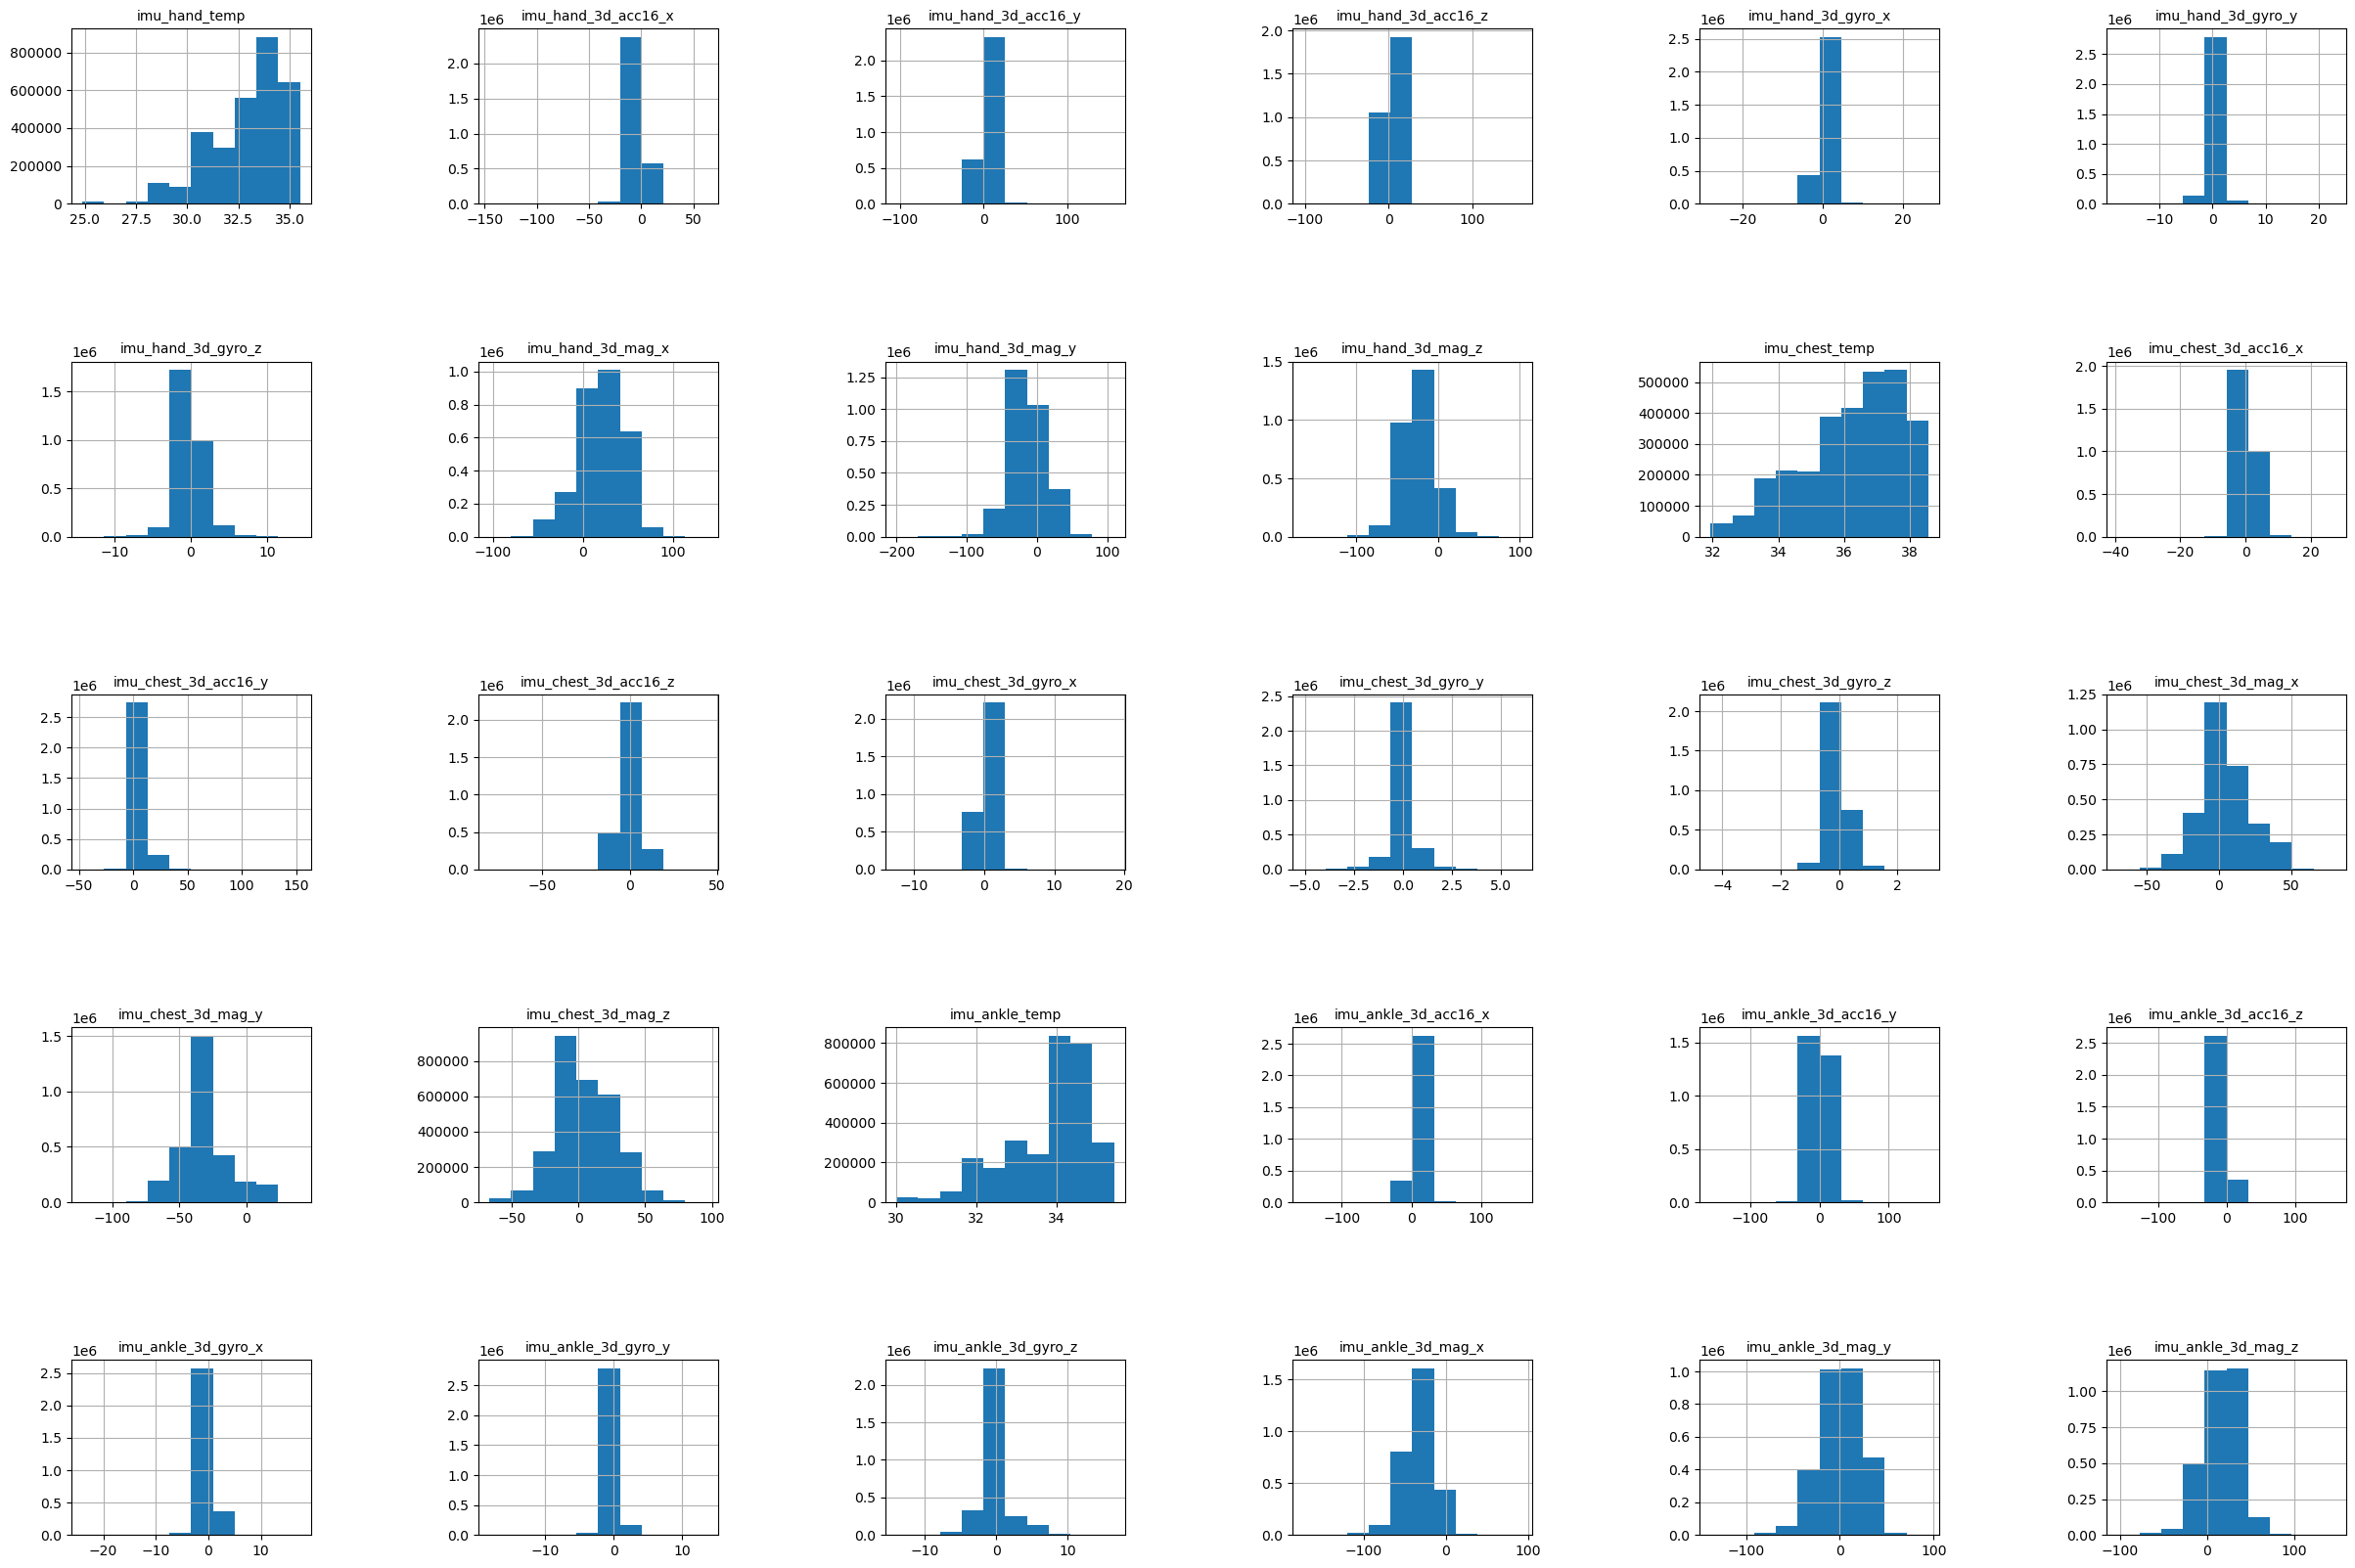

In [35]:
fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(30, 20))
all_subjects_df.hist(ax=axes)


for ax in axes.flatten():
    ax.set_title(ax.get_title(), fontsize=10)

plt.subplots_adjust(hspace=0.9, wspace=0.7)

## 9.⁠ ⁠Genera la gráfica de densidad para la distribución de los atributos de cada base de datos.

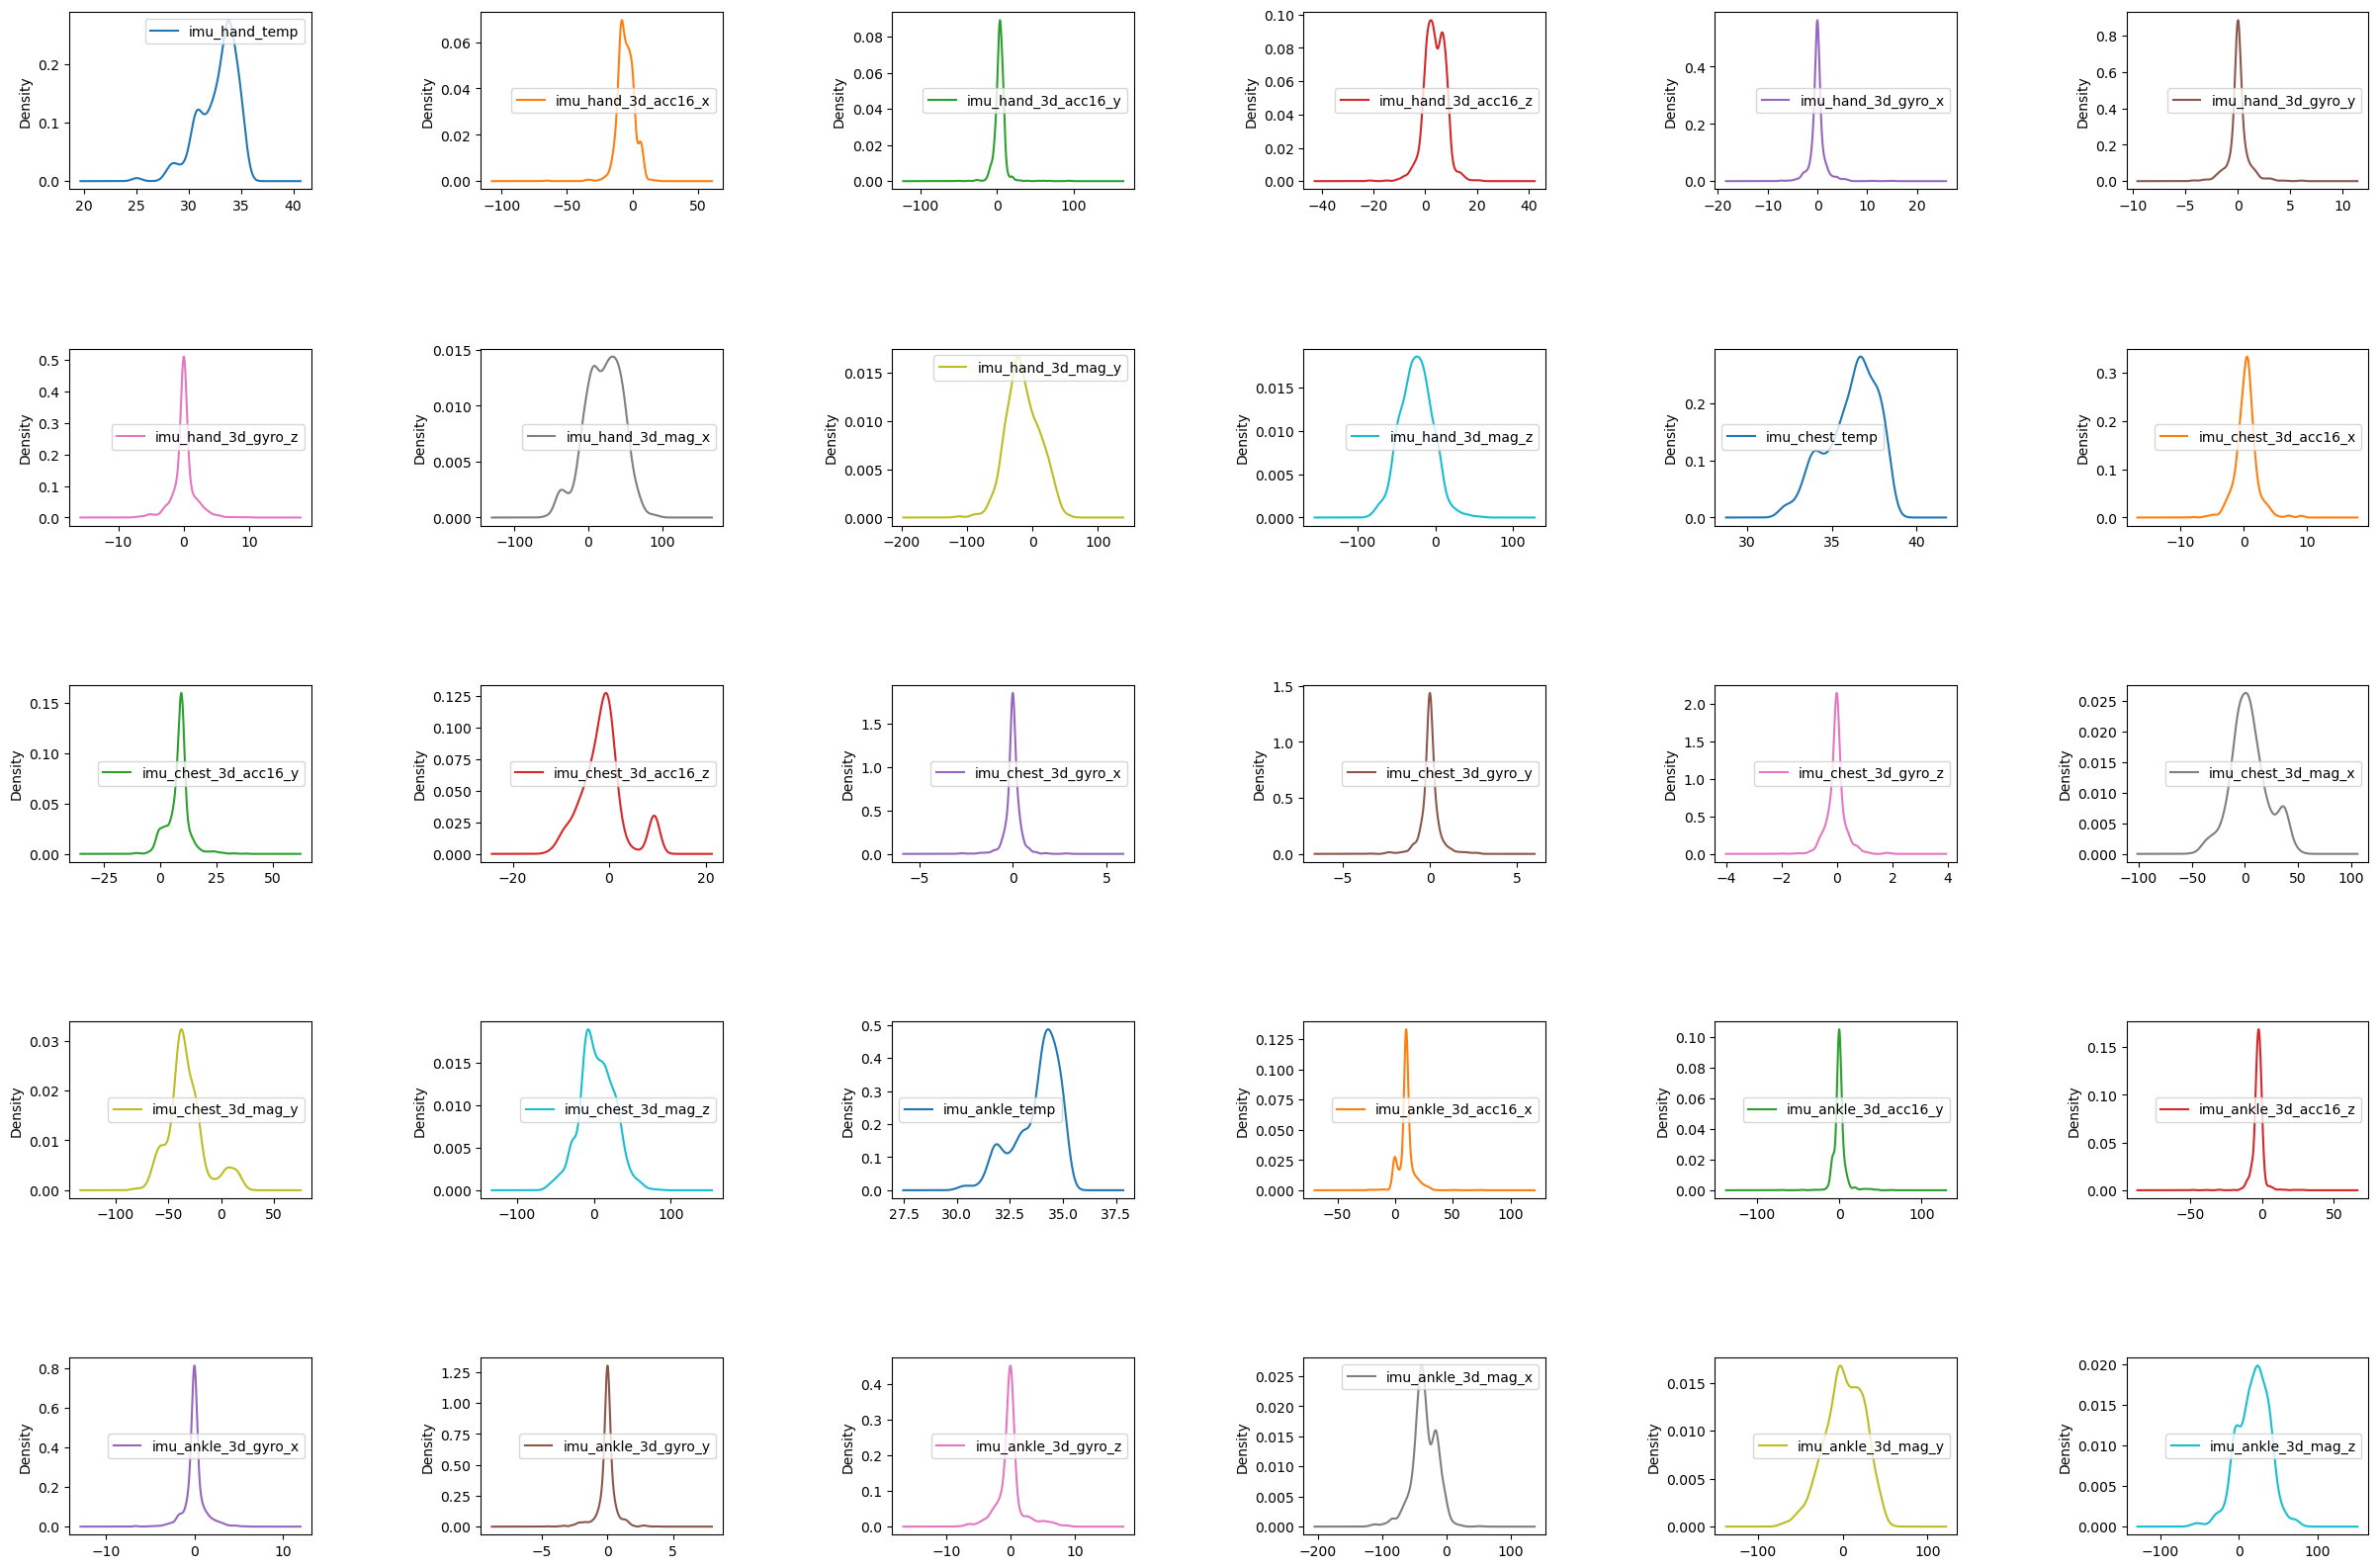

In [37]:
small_df = all_subjects_df.sample(n=1000, random_state=42)

small_df.plot(kind='density', subplots=True, layout=(5, 6), figsize=(30, 20), sharex=False)

plt.subplots_adjust(hspace=0.9, wspace=0.7)

## 10.Genera la gráfica de cajas y bigotes para la distribución de los atributos de cada base de datos.

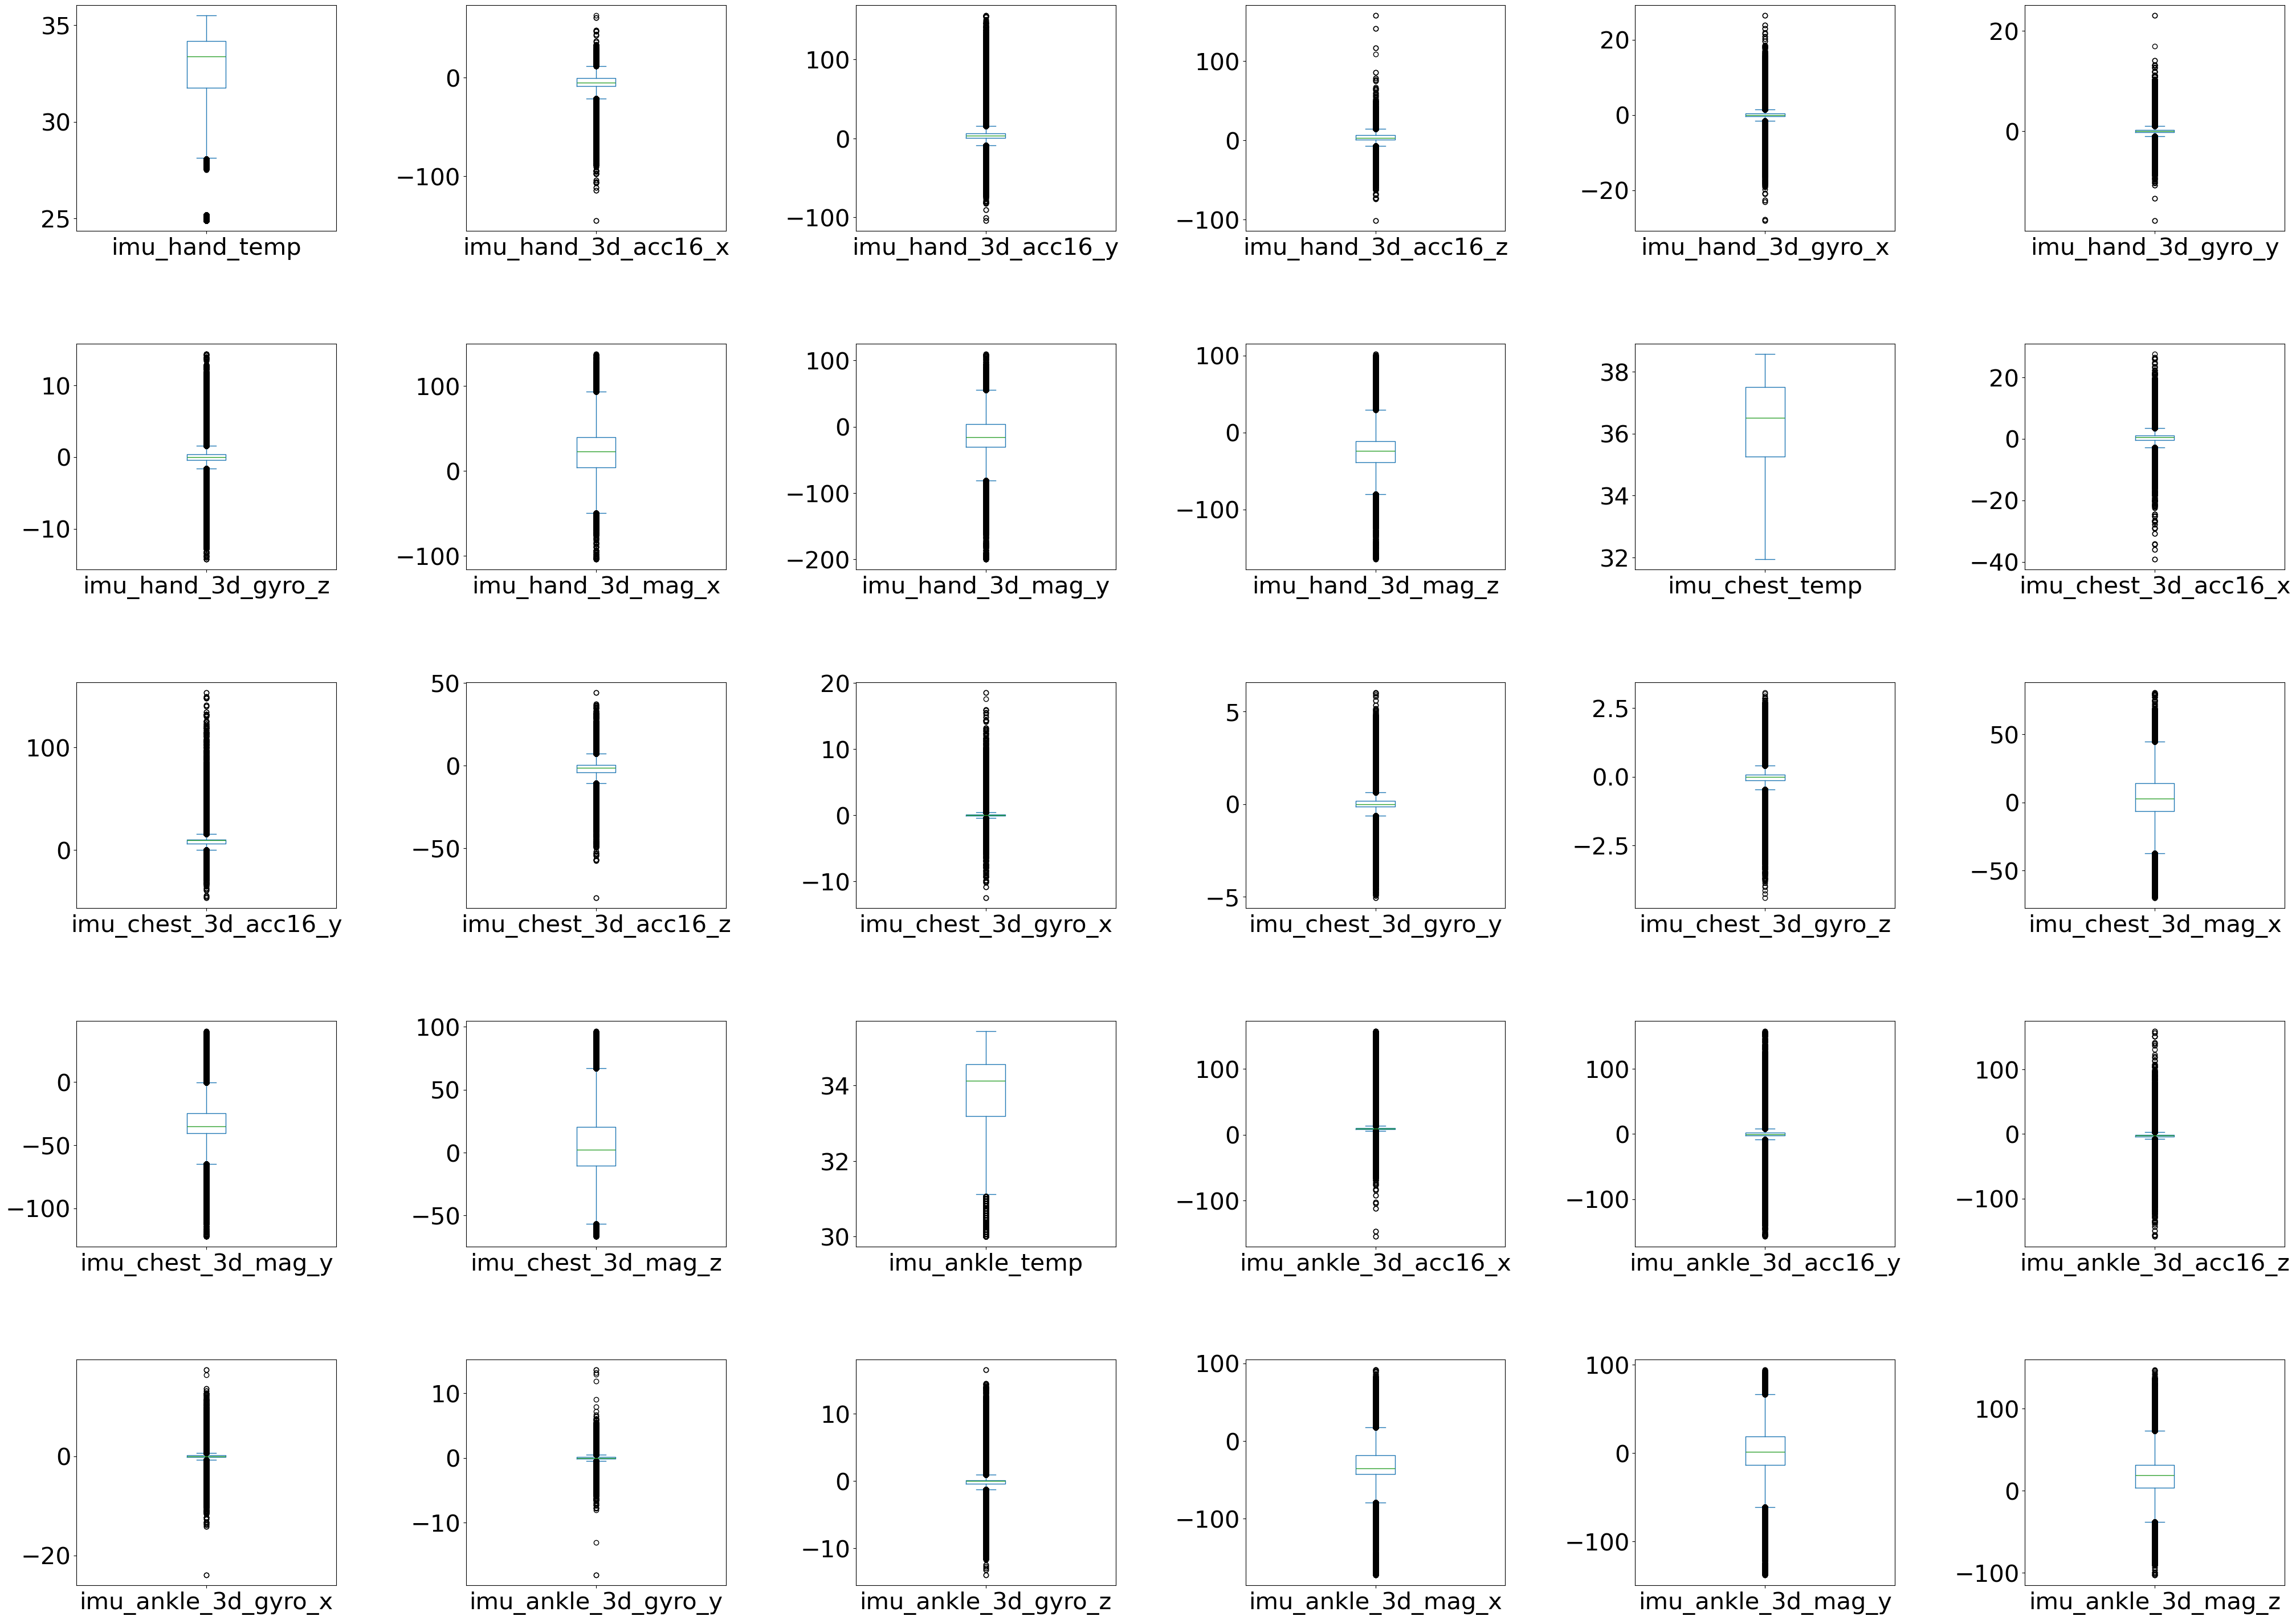

In [39]:
all_subjects_df.plot(kind='box', subplots=True, layout=(5,6), figsize=(50, 36), sharex=False,sharey=False)


plt.subplots_adjust(hspace=0.5, wspace=0.5)

for ax in plt.gcf().axes:
    ax.title.set_fontsize(50)  # Increase title font size
    ax.xaxis.label.set_fontsize(30)  # Increase x-axis label font size
    ax.yaxis.label.set_fontsize(15)  # Increase y-axis label font size
    ax.tick_params(axis='x', labelsize=30)  # Increase x-tick font size
    ax.tick_params(axis='y', labelsize=30)  # Increase y-tick font size

## 11.Genera la matriz de correlación de los atributos para cada una de las bases de datos.

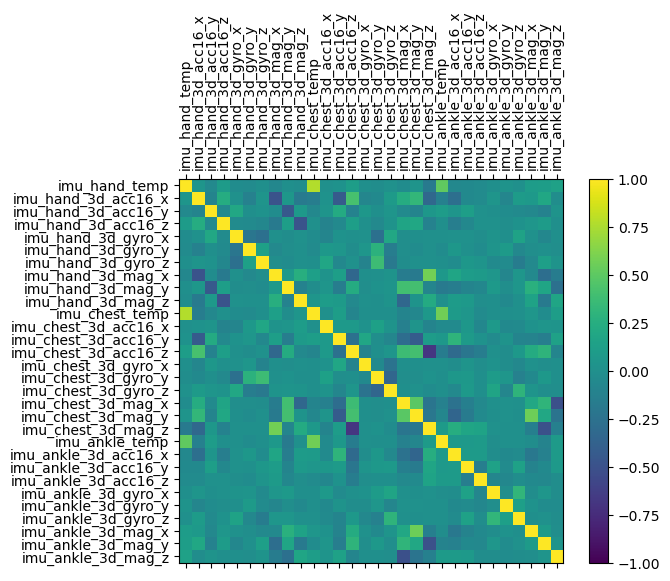

In [41]:
correlations = all_subjects_df.corr()
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(0,len(all_subjects_df.columns),1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(all_subjects_df.columns, rotation=90)
ax.set_yticklabels(all_subjects_df.columns)

plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9)


## 12.Genera la matriz de dispersión de los atributos para cada base de datos.

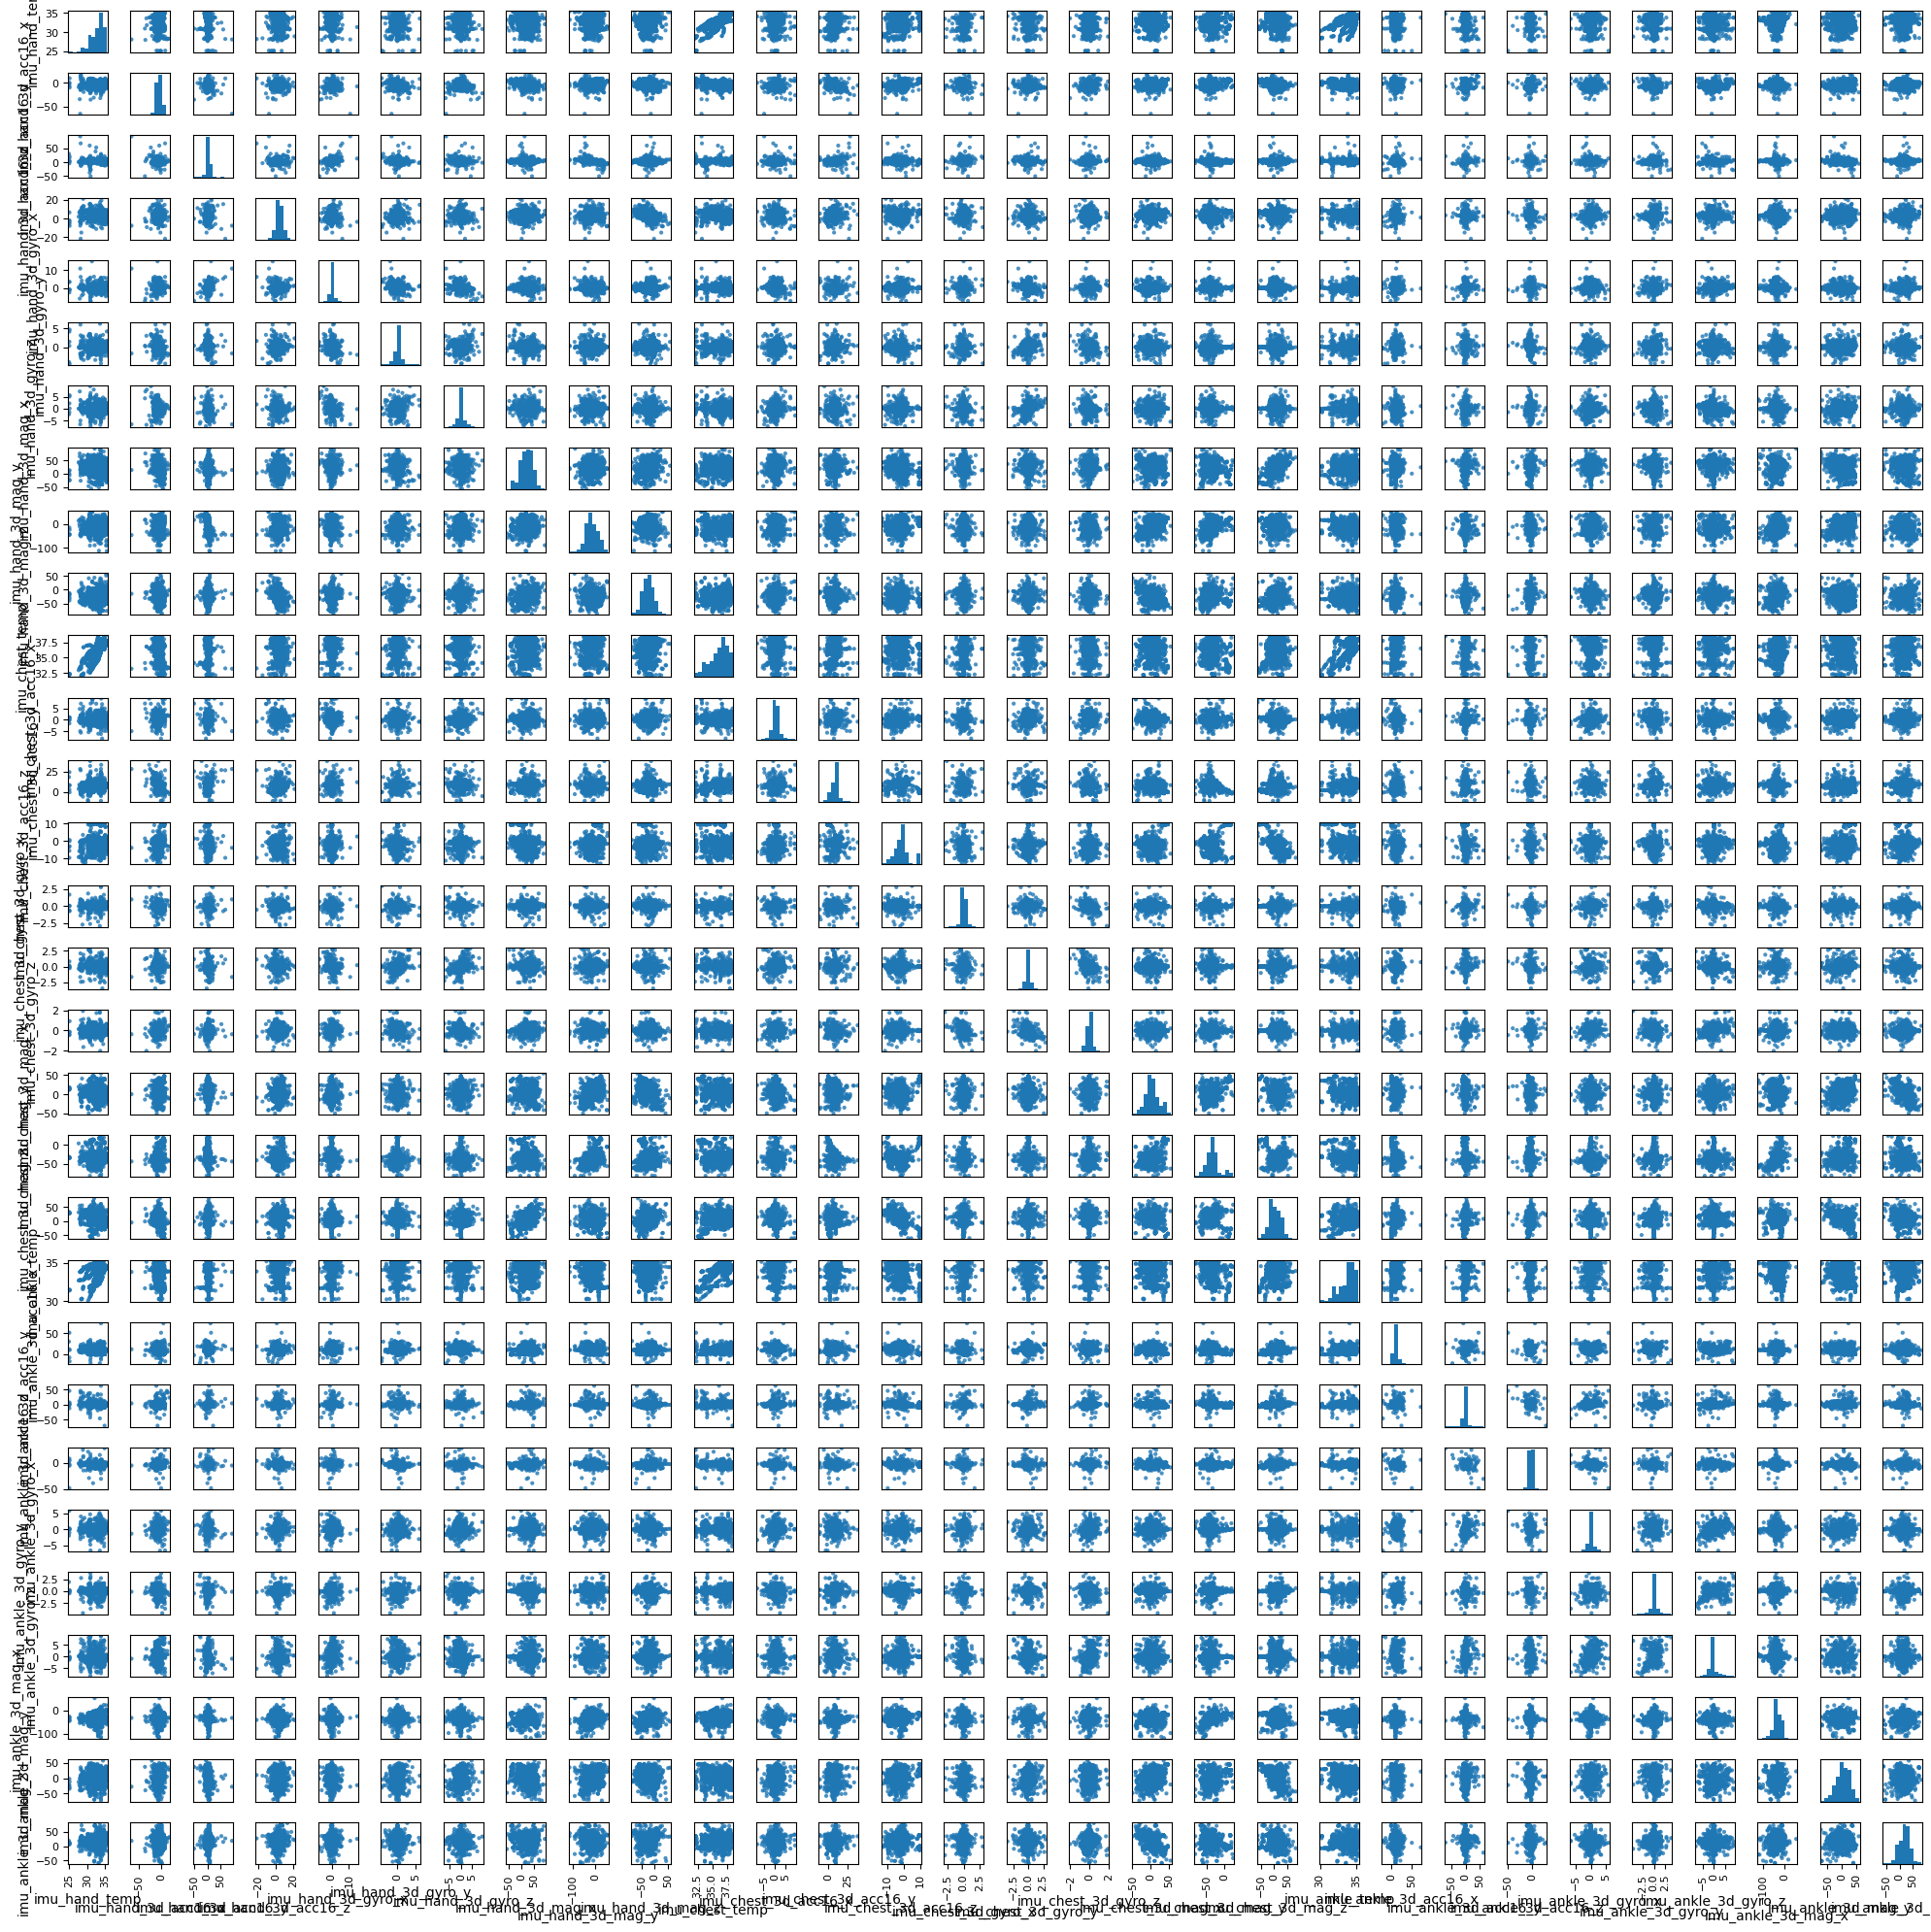

In [43]:
from pandas.plotting import scatter_matrix

small_df2 = all_subjects_df.sample(n=1000, random_state=42)

scatter_matrix(small_df2, figsize=(20, 20), diagonal='hist', alpha=0.8)

plt.xticks(rotation=90)  # Rotate x-axis labels
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

## 13.Aplica escalamiento, normalización o estandarización según sea el caso a cada base de datos.

In [45]:
all_subjects_df.describe()

,imu_hand_temp,imu_hand_3d_acc16_x,imu_hand_3d_acc16_y,imu_hand_3d_acc16_z,imu_hand_3d_gyro_x,imu_hand_3d_gyro_y,imu_hand_3d_gyro_z,imu_hand_3d_mag_x,imu_hand_3d_mag_y,imu_hand_3d_mag_z,...,imu_ankle_temp,imu_ankle_3d_acc16_x,imu_ankle_3d_acc16_y,imu_ankle_3d_acc16_z,imu_ankle_3d_gyro_x,imu_ankle_3d_gyro_y,imu_ankle_3d_gyro_z,imu_ankle_3d_mag_x,imu_ankle_3d_mag_y,imu_ankle_3d_mag_z
count,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06,...,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06,2.983860e+06
mean,3.288911e+01,-4.843648e+00,3.387671e+00,3.578807e+00,3.754376e-05,4.675135e-02,-1.720443e-03,2.083343e+01,-1.367858e+01,-2.462691e+01,...,3.380049e+01,9.417980e+00,-8.236108e-02,-2.735644e+00,1.290390e-02,-3.214379e-02,6.664148e-03,-3.291670e+01,1.696246e+00,1.722014e+01
std,1.819763e+00,6.439462e+00,7.498813e+00,3.989837e+00,1.339092e+00,9.749547e-01,1.643468e+00,2.479500e+01,2.562783e+01,2.043493e+01,...,1.053295e+00,6.732717e+00,7.887772e+00,4.017350e+00,1.139250e+00,6.517277e-01,2.062535e+00,1.885233e+01,2.265289e+01,2.022283e+01
min,2.487500e+01,-1.453670e+02,-1.043010e+02,-1.014520e+02,-2.813540e+01,-1.784950e+01,-1.426470e+01,-1.039410e+02,-2.000430e+02,-1.649370e+02,...,3.000000e+01,-1.550680e+02,-1.574430e+02,-1.589260e+02,-2.399500e+01,-1.812690e+01,-1.401960e+01,-1.728650e+02,-1.379080e+02,-1.027160e+02
25%,3.175000e+01,-8.903150e+00,4.201760e-01,1.163270e+00,-3.939970e-01,-2.286233e-01,-4.021465e-01,4.096430e+00,-3.019040e+01,-3.907080e+01,...,3.318750e+01,8.318600e+00,-2.177410e+00,-3.900440e+00,-2.045690e-01,-1.108060e-01,-4.406970e-01,-4.280390e+01,-1.316202e+01,3.498650e+00
50%,3.337500e+01,-5.263835e+00,3.429915e+00,3.470620e+00,-6.652550e-03,6.190650e-03,-5.545485e-03,2.270335e+01,-1.574200e+01,-2.409720e+01,...,3.412500e+01,9.515470e+00,-2.740260e-01,-2.549270e+00,5.229750e-03,-3.182340e-03,-1.844505e-03,-3.496000e+01,1.846350e+00,1.858245e+01
75%,3.418750e+01,-6.104510e-01,6.555363e+00,6.458592e+00,3.454257e-01,2.776280e-01,3.956760e-01,3.991260e+01,3.978575e+00,-1.155165e+01,...,3.456250e+01,1.033900e+01,1.914550e+00,-1.182610e+00,1.482190e-01,1.266295e-01,1.088890e-01,-1.861850e+01,1.877560e+01,3.133500e+01
max,3.550000e+01,6.285960e+01,1.556990e+02,1.577600e+02,2.641580e+01,2.307790e+01,1.433840e+01,1.375440e+02,1.094870e+02,1.017580e+02,...,3.543750e+01,1.572320e+02,1.572930e+02,1.588720e+02,1.742040e+01,1.358820e+01,1.652880e+01,9.155160e+01,9.424780e+01,1.469000e+02


In [46]:
all_subjects_df.describe().map(lambda x: "{:.6f}".format(x))

,imu_hand_temp,imu_hand_3d_acc16_x,imu_hand_3d_acc16_y,imu_hand_3d_acc16_z,imu_hand_3d_gyro_x,imu_hand_3d_gyro_y,imu_hand_3d_gyro_z,imu_hand_3d_mag_x,imu_hand_3d_mag_y,imu_hand_3d_mag_z,...,imu_ankle_temp,imu_ankle_3d_acc16_x,imu_ankle_3d_acc16_y,imu_ankle_3d_acc16_z,imu_ankle_3d_gyro_x,imu_ankle_3d_gyro_y,imu_ankle_3d_gyro_z,imu_ankle_3d_mag_x,imu_ankle_3d_mag_y,imu_ankle_3d_mag_z
count,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,...,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000
mean,32.889112,-4.843648,3.387671,3.578807,0.000038,0.046751,-0.001720,20.833429,-13.678578,-24.626906,...,33.800492,9.417980,-0.082361,-2.735644,0.012904,-0.032144,0.006664,-32.916695,1.696246,17.220143
std,1.819763,6.439462,7.498813,3.989837,1.339092,0.974955,1.643468,24.795004,25.627833,20.434930,...,1.053295,6.732717,7.887772,4.017350,1.139250,0.651728,2.062535,18.852327,22.652890,20.222827
min,24.875000,-145.367000,-104.301000,-101.452000,-28.135400,-17.849500,-14.264700,-103.941000,-200.043000,-164.937000,...,30.000000,-155.068000,-157.443000,-158.926000,-23.995000,-18.126900,-14.019600,-172.865000,-137.908000,-102.716000
25%,31.750000,-8.903150,0.420176,1.163270,-0.393997,-0.228623,-0.402146,4.096430,-30.190400,-39.070800,...,33.187500,8.318600,-2.177410,-3.900440,-0.204569,-0.110806,-0.440697,-42.803900,-13.162025,3.498650
50%,33.375000,-5.263835,3.429915,3.470620,-0.006653,0.006191,-0.005545,22.703350,-15.742000,-24.097200,...,34.125000,9.515470,-0.274026,-2.549270,0.005230,-0.003182,-0.001845,-34.960000,1.846350,18.582450
75%,34.187500,-0.610451,6.555363,6.458592,0.345426,0.277628,0.395676,39.912600,3.978575,-11.551650,...,34.562500,10.339000,1.914550,-1.182610,0.148219,0.126630,0.108889,-18.618500,18.775600,31.335000
max,35.500000,62.859600,155.699000,157.760000,26.415800,23.077900,14.338400,137.544000,109.487000,101.758000,...,35.437500,157.232000,157.293000,158.872000,17.420400,13.588200,16.528800,91.551600,94.247800,146.900000


In [47]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()

### Estandarización de los datos de los ejes de los sensores

In [49]:
axis_columns = [column for column in all_subjects_df.columns if "3d" in column]
axis_columns

['imu_hand_3d_acc16_x',
 'imu_hand_3d_acc16_y',
 'imu_hand_3d_acc16_z',
 'imu_hand_3d_gyro_x',
 'imu_hand_3d_gyro_y',
 'imu_hand_3d_gyro_z',
 'imu_hand_3d_mag_x',
 'imu_hand_3d_mag_y',
 'imu_hand_3d_mag_z',
 'imu_chest_3d_acc16_x',
 'imu_chest_3d_acc16_y',
 'imu_chest_3d_acc16_z',
 'imu_chest_3d_gyro_x',
 'imu_chest_3d_gyro_y',
 'imu_chest_3d_gyro_z',
 'imu_chest_3d_mag_x',
 'imu_chest_3d_mag_y',
 'imu_chest_3d_mag_z',
 'imu_ankle_3d_acc16_x',
 'imu_ankle_3d_acc16_y',
 'imu_ankle_3d_acc16_z',
 'imu_ankle_3d_gyro_x',
 'imu_ankle_3d_gyro_y',
 'imu_ankle_3d_gyro_z',
 'imu_ankle_3d_mag_x',
 'imu_ankle_3d_mag_y',
 'imu_ankle_3d_mag_z']

In [50]:
all_subjects_df[axis_columns] = scaler.fit_transform(all_subjects_df[axis_columns].values)

In [51]:
all_subjects_df

,,imu_hand_temp,imu_hand_3d_acc16_x,imu_hand_3d_acc16_y,imu_hand_3d_acc16_z,imu_hand_3d_gyro_x,imu_hand_3d_gyro_y,imu_hand_3d_gyro_z,imu_hand_3d_mag_x,imu_hand_3d_mag_y,imu_hand_3d_mag_z,...,imu_ankle_temp,imu_ankle_3d_acc16_x,imu_ankle_3d_acc16_y,imu_ankle_3d_acc16_z,imu_ankle_3d_gyro_x,imu_ankle_3d_gyro_y,imu_ankle_3d_gyro_z,imu_ankle_3d_mag_x,imu_ankle_3d_mag_y,imu_ankle_3d_mag_z
timestamp,activity_id,,,,,,,,,,,,,,,,,,,,,
37.66,1,30.375,1.096202,0.652301,0.503460,-0.003575,-0.009408,-0.005735,-0.479993,-2.116996,0.227620,...,30.75,0.047614,-0.223796,0.704644,-0.008774,0.006797,-0.002381,-1.495381,-1.702205,-3.737843
37.67,1,30.375,1.108106,0.571452,0.542845,-0.128257,-0.021819,-0.004757,-0.453738,-2.118003,0.181934,...,30.75,0.041535,-0.228457,0.675779,0.007003,0.050770,-0.000319,-1.483897,-1.678194,-3.737645
37.68,1,30.375,1.107942,0.500710,0.562583,-0.177940,-0.036451,0.001552,-0.475026,-2.096281,0.250483,...,30.75,0.041343,-0.233231,0.666228,-0.042393,-0.031114,-0.005598,-1.454675,-1.654555,-3.749825
37.69,1,30.375,1.096621,0.500877,0.581601,-0.144090,-0.028409,0.009185,-0.439865,-2.097724,0.199008,...,30.75,0.036496,-0.223736,0.704452,-0.039866,0.020408,0.009835,-1.477160,-1.712764,-3.713628
37.70,1,30.375,1.109520,0.516202,0.630047,-0.052273,-0.066751,0.003835,-0.470949,-2.087727,0.222228,...,30.75,0.053144,-0.228640,0.704798,-0.010140,-0.025677,-0.006299,-1.447424,-1.713634,-3.713865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95.06,24,25.125,1.527815,0.350874,0.506159,-0.215970,-0.160952,0.146209,-1.033554,-0.173582,-1.156970,...,31.50,-0.001591,-0.274051,0.118462,0.007360,0.029550,-0.000381,-0.682611,-0.111596,-0.859933
95.07,24,25.125,1.532937,0.335522,0.477441,-0.205698,-0.179608,0.163757,-1.023369,-0.169282,-1.189135,...,31.50,-0.007505,-0.278753,0.099206,-0.001922,0.054889,-0.005284,-0.695745,-0.110959,-0.824910
95.08,24,25.125,1.538597,0.310186,0.477740,-0.216507,-0.177751,0.172321,-1.008568,-0.165192,-1.163513,...,31.50,-0.007475,-0.273939,0.099146,-0.026195,-0.004652,-0.004350,-0.668210,-0.129152,-0.824796


### Escalamiento de las temperaturas

In [53]:
minmaxscaler = MinMaxScaler()

In [54]:
all_subjects_df

,,imu_hand_temp,imu_hand_3d_acc16_x,imu_hand_3d_acc16_y,imu_hand_3d_acc16_z,imu_hand_3d_gyro_x,imu_hand_3d_gyro_y,imu_hand_3d_gyro_z,imu_hand_3d_mag_x,imu_hand_3d_mag_y,imu_hand_3d_mag_z,...,imu_ankle_temp,imu_ankle_3d_acc16_x,imu_ankle_3d_acc16_y,imu_ankle_3d_acc16_z,imu_ankle_3d_gyro_x,imu_ankle_3d_gyro_y,imu_ankle_3d_gyro_z,imu_ankle_3d_mag_x,imu_ankle_3d_mag_y,imu_ankle_3d_mag_z
timestamp,activity_id,,,,,,,,,,,,,,,,,,,,,
37.66,1,30.375,1.096202,0.652301,0.503460,-0.003575,-0.009408,-0.005735,-0.479993,-2.116996,0.227620,...,30.75,0.047614,-0.223796,0.704644,-0.008774,0.006797,-0.002381,-1.495381,-1.702205,-3.737843
37.67,1,30.375,1.108106,0.571452,0.542845,-0.128257,-0.021819,-0.004757,-0.453738,-2.118003,0.181934,...,30.75,0.041535,-0.228457,0.675779,0.007003,0.050770,-0.000319,-1.483897,-1.678194,-3.737645
37.68,1,30.375,1.107942,0.500710,0.562583,-0.177940,-0.036451,0.001552,-0.475026,-2.096281,0.250483,...,30.75,0.041343,-0.233231,0.666228,-0.042393,-0.031114,-0.005598,-1.454675,-1.654555,-3.749825
37.69,1,30.375,1.096621,0.500877,0.581601,-0.144090,-0.028409,0.009185,-0.439865,-2.097724,0.199008,...,30.75,0.036496,-0.223736,0.704452,-0.039866,0.020408,0.009835,-1.477160,-1.712764,-3.713628
37.70,1,30.375,1.109520,0.516202,0.630047,-0.052273,-0.066751,0.003835,-0.470949,-2.087727,0.222228,...,30.75,0.053144,-0.228640,0.704798,-0.010140,-0.025677,-0.006299,-1.447424,-1.713634,-3.713865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95.06,24,25.125,1.527815,0.350874,0.506159,-0.215970,-0.160952,0.146209,-1.033554,-0.173582,-1.156970,...,31.50,-0.001591,-0.274051,0.118462,0.007360,0.029550,-0.000381,-0.682611,-0.111596,-0.859933
95.07,24,25.125,1.532937,0.335522,0.477441,-0.205698,-0.179608,0.163757,-1.023369,-0.169282,-1.189135,...,31.50,-0.007505,-0.278753,0.099206,-0.001922,0.054889,-0.005284,-0.695745,-0.110959,-0.824910
95.08,24,25.125,1.538597,0.310186,0.477740,-0.216507,-0.177751,0.172321,-1.008568,-0.165192,-1.163513,...,31.50,-0.007475,-0.273939,0.099146,-0.026195,-0.004652,-0.004350,-0.668210,-0.129152,-0.824796


In [55]:
temperature_columns = [column for column in all_subjects_df.columns if column not in axis_columns]
temperature_columns

['imu_hand_temp', 'imu_chest_temp', 'imu_ankle_temp']

In [56]:
all_subjects_df[temperature_columns] = scaler.fit_transform(all_subjects_df[temperature_columns].values)

In [57]:
all_subjects_df.describe().map(lambda x: "{:.6f}".format(x))

,imu_hand_temp,imu_hand_3d_acc16_x,imu_hand_3d_acc16_y,imu_hand_3d_acc16_z,imu_hand_3d_gyro_x,imu_hand_3d_gyro_y,imu_hand_3d_gyro_z,imu_hand_3d_mag_x,imu_hand_3d_mag_y,imu_hand_3d_mag_z,...,imu_ankle_temp,imu_ankle_3d_acc16_x,imu_ankle_3d_acc16_y,imu_ankle_3d_acc16_z,imu_ankle_3d_gyro_x,imu_ankle_3d_gyro_y,imu_ankle_3d_gyro_z,imu_ankle_3d_mag_x,imu_ankle_3d_mag_y,imu_ankle_3d_mag_z
count,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,...,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000,2983860.000000
mean,-0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,...,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000
std,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
min,-4.403933,-21.822222,-14.360765,-26.324593,-21.010831,-18.355985,-8.678590,-5.032242,-7.271955,-6.866190,...,-3.608193,-24.430853,-19.949951,-38.878960,-21.073425,-27.764293,-6.800497,-7.423398,-6.162757,-5.930732
25%,-0.625968,-0.630410,-0.395729,-0.605423,-0.294255,-0.282449,-0.243647,-0.675015,-0.644293,-0.706824,...,-0.581975,-0.163289,-0.265607,-0.289942,-0.190891,-0.120698,-0.216899,-0.524455,-0.655911,-0.678515
50%,0.267006,-0.065252,0.005633,-0.027116,-0.004996,-0.041603,-0.002327,0.075415,-0.080515,0.025922,...,0.308089,0.014480,-0.024299,0.046392,-0.006736,0.044438,-0.004125,-0.108385,0.006626,0.067365
75%,0.713493,0.657384,0.422426,0.721780,0.257927,0.236808,0.241804,0.769477,0.688984,0.639848,...,0.723452,0.136798,0.253165,0.386582,0.118776,0.243619,0.049563,0.758431,0.753959,0.697967
max,1.434741,10.513806,20.311396,38.643492,19.726621,23.622792,8.725528,4.707021,4.805931,6.184750,...,1.554178,21.954592,19.951817,40.227433,15.279783,20.898829,8.010597,6.602279,4.085641,6.412550
